In [1]:
import pandas as pd
df =pd.read_csv("employee_salary_prediction_2500_updated.csv")
df.head()

,Employee_ID,Age,Experience_Years,Education,Department,Job_Level,Performance_Rating,Projects_Completed,Certifications,Weekly_Work_Hours,Remote_Work,City_Tier,Job_Satisfaction,Salary_LPA,Salary_Status
0,10001,59,34,Bachelor,Marketing,9,3.7,30,13,38.1,No,Tier 2,5,50.00,High
1,10002,49,29,Bachelor,HR,9,3.2,25,10,48.3,No,Tier 2,1,46.78,High
2,10003,35,10,Bachelor,IT,4,3.1,13,4,41.7,No,Tier 1,2,27.53,Low
3,10004,28,3,Master,Operations,1,3.1,7,3,41.8,No,Tier 1,4,17.94,Low
4,10005,41,18,Master,IT,5,2.6,18,7,47.2,No,Tier 1,5,36.39,High


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
df.to_csv("preprocessed_data_1.csv")
df.head()

,Employee_ID,Age,Experience_Years,Education,Department,Job_Level,Performance_Rating,Projects_Completed,Certifications,Weekly_Work_Hours,Remote_Work,City_Tier,Job_Satisfaction,Salary_LPA,Salary_Status
0,10001,59,34,Bachelor,Marketing,9,3.7,30,13,38.1,No,Tier 2,5,50.00,High
1,10002,49,29,Bachelor,HR,9,3.2,25,10,48.3,No,Tier 2,1,46.78,High
2,10003,35,10,Bachelor,IT,4,3.1,13,4,41.7,No,Tier 1,2,27.53,Low
3,10004,28,3,Master,Operations,1,3.1,7,3,41.8,No,Tier 1,4,17.94,Low
4,10005,41,18,Master,IT,5,2.6,18,7,47.2,No,Tier 1,5,36.39,High


In [3]:
df.to_csv("preprocessed_data_1.csv",index=False)
print("saved")

saved


In [4]:
df.columns

Index(['Employee_ID', 'Age', 'Experience_Years', 'Education', 'Department',
       'Job_Level', 'Performance_Rating', 'Projects_Completed',
       'Certifications', 'Weekly_Work_Hours', 'Remote_Work', 'City_Tier',
       'Job_Satisfaction', 'Salary_LPA', 'Salary_Status'],
      dtype='str')

In [5]:
x = df.drop("Salary_LPA",axis=1)
y = df["Salary_LPA"]
x = pd.get_dummies(x,drop_first=True)
x_train , x_test , y_train , y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Features: ",x_train.shape)
print("Testing Features: ",x_test.shape)

print("Training Target: ",y_train.shape)
print("Training Target: ",y_test.shape)
print("Training data")
print(x_train.head())

print("\nTesting data")
print(x_test.head())

Training Features:  (2000, 22)
Testing Features:  (500, 22)
Training Target:  (2000,)
Training Target:  (500,)
Training data
      Employee_ID  Age  Experience_Years  Job_Level  Performance_Rating  \
2055        12056   41                17          6                 3.7   
1961        11962   54                33         10                 4.7   
1864        11865   30                 8          3                 3.6   
2326        12327   40                19          5                 3.3   
461         10462   49                25          8                 2.7   

      Projects_Completed  Certifications  Weekly_Work_Hours  Job_Satisfaction  \
2055                  13               8               45.6                 2   
1961                  33              13               45.5                 3   
1864                   9               2               38.5                 5   
2326                  18               8               40.7                 4   
461                

In [6]:
df['Performance_Rating']

0       3.7
1       3.2
2       3.1
3       3.1
4       2.6
       ... 
2495    4.8
2496    3.9
2497    3.8
2498    2.9
2499    2.7
Name: Performance_Rating, Length: 2500, dtype: float64

In [7]:
df['Salary_LPA']

0       50.00
1       46.78
2       27.53
3       17.94
4       36.39
        ...  
2495    50.00
2496    48.35
2497    16.65
2498    34.52
2499    50.00
Name: Salary_LPA, Length: 2500, dtype: float64

In [8]:
import numpy as np
X = df['Performance_Rating']
Y = df['Salary_LPA']
m = ((X - X.mean()) * (Y - Y.mean())).sum() / ((X - X.mean()) ** 2).sum()
c = Y.mean() - m * X.mean()
Y_pred = m * X + c
print(Y_pred)
Y_pred = np.round(Y_pred).astype(int)
print(Y_pred.head())
print("Slope: ", m)
print("Intercept: ", c)

0       34.245480
1       33.804755
2       33.716610
3       33.716610
4       33.275885
          ...    
2495    35.215074
2496    34.421769
2497    34.333625
2498    33.540320
2499    33.364030
Name: Performance_Rating, Length: 2500, dtype: float64
0    34
1    34
2    34
3    34
4    33
Name: Performance_Rating, dtype: int64
Slope:  0.8814492571665522
Intercept:  30.984117373827925


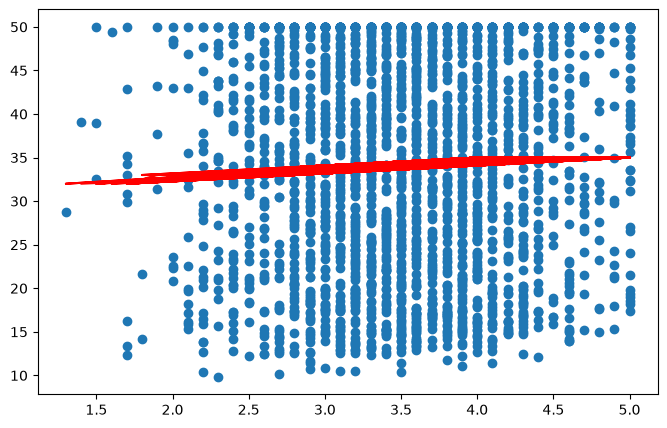

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(X,Y)
plt.plot(X,Y_pred,color = "red")
plt.title = ("simple Linear chart")
plt.xlabel = ("Performance_Rating")
plt.ylabel = ("Salary LPA")
plt.show()

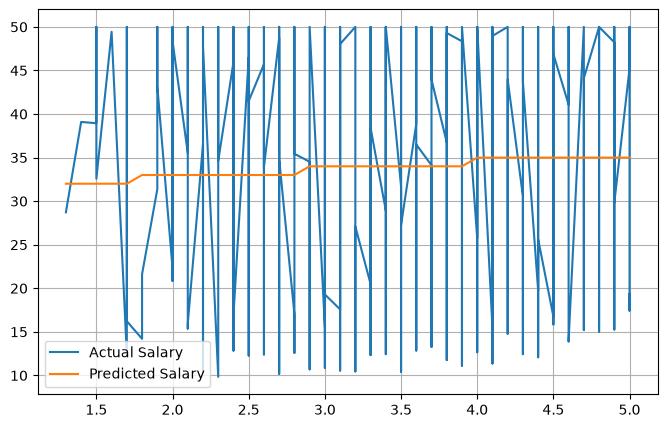

In [10]:
import matplotlib.pyplot as plt
sorted_data = pd.DataFrame({
    "X":X,
    "Actual" : Y,
    "Predicted":Y_pred
}).sort_values("X")
plt.figure(figsize=(8,5))
plt.plot(sorted_data["X"],sorted_data["Actual"],label="Actual Salary")
plt.plot(sorted_data["X"],sorted_data["Predicted"],label="Predicted Salary")
plt.title = ("Actual vs Predicted Salary")
plt.xlabel = ("Performance_Rating")
plt.ylabel = ("Salary LPA")
plt.legend()
plt.grid(True)
plt.show()

Intercept(b0):  31.32960491699808
Slope(b1):  0.7629162497504562

Regression Equation:
Salary = 31.32960491699808 + 0.7629162497504562 * Performance_Rating
   Performance_Rating  Actual Salary  Predicted Salary
0                 3.1          50.00                34
1                 3.6          13.79                34
2                 2.5          30.66                33
3                 4.5          40.00                35
4                 4.6          49.89                35
5                 3.1          50.00                34
6                 4.1          26.70                34
7                 2.9          18.58                34
8                 4.1          15.49                34
9                 2.7          34.83                33


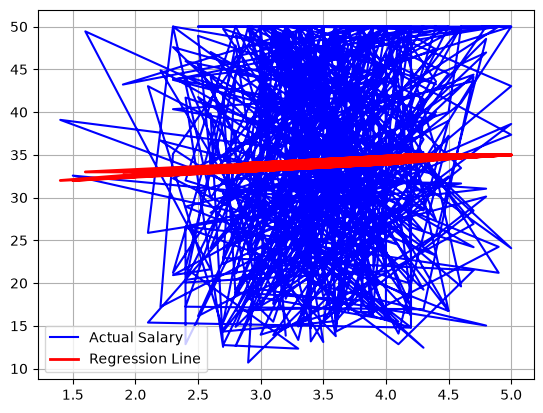

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   
df=pd.read_csv(r'preprocessed_data_1.csv')
df.head()

X = df[['Performance_Rating']]
y = df['Salary_LPA']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept(b0): ", model.intercept_)
print("Slope(b1): ", model.coef_[0])
print("\nRegression Equation:")
print(f"Salary = {model.intercept_} + {model.coef_[0]} * Performance_Rating")
y_pred=model.predict(X_test)
y_pred = np.round(y_pred).astype(int)
result=pd.DataFrame({"Performance_Rating": X_test["Performance_Rating"].values,
                    "Actual Salary": y_test.values,
                    "Predicted Salary": y_pred})
print(result.head(10))
plot_data = pd.DataFrame({
    "Performance_Rating": X_test["Performance_Rating"].values,
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred})
plt.plot(
    plot_data["Performance_Rating"],
    plot_data["Actual Salary"],
    color="blue",
    label="Actual Salary"
)
plt.plot(
    plot_data["Performance_Rating"],
    plot_data["Predicted Salary"],
    color="red",
    linewidth=2,
    label="Regression Line"
)
plt.title = ("Linear Regression using scikit-learn")
plt.xlabel = ("Performance_Rating")
plt.ylabel = ("Salary_LPA")
plt.legend()
plt.grid(True)
plt.show()